# Example-03: Estimator bias

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

w1: 2.09465512e-05 2.2936407e-06
w2: 3.7373038e-09 4.98039843e-09


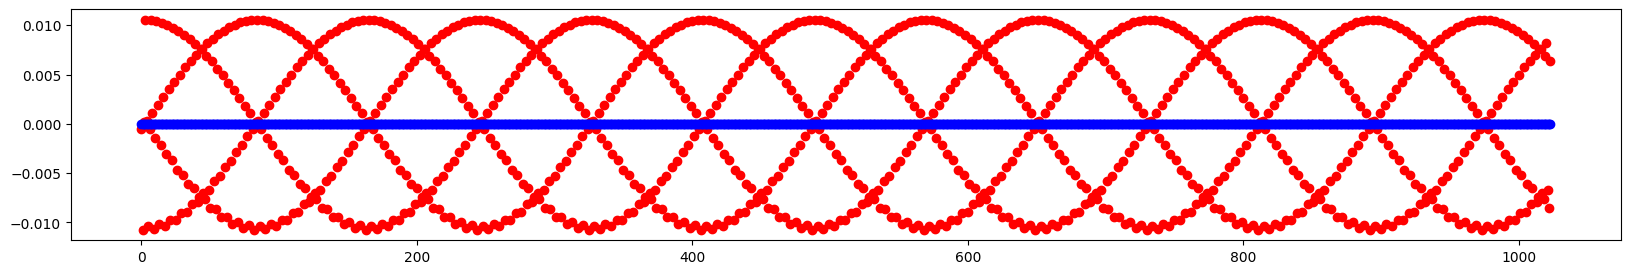

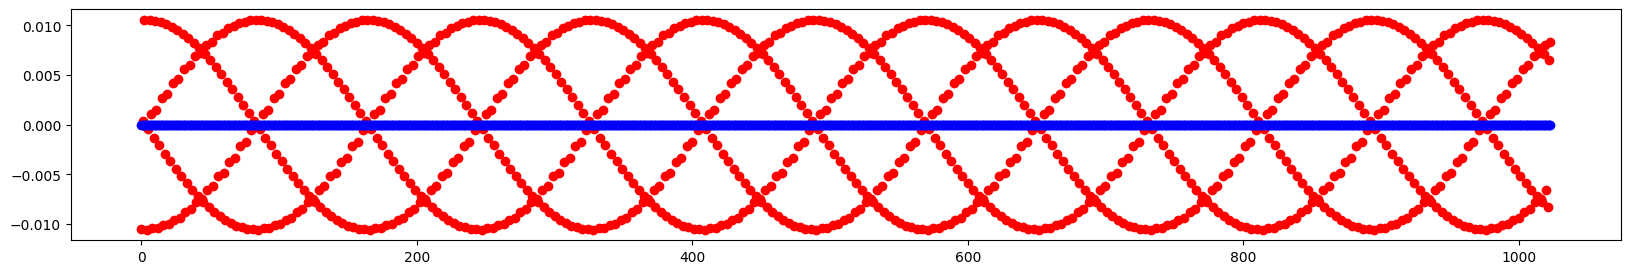

In [3]:
# Given a noise-free signal containing several components
# Parameters for a given frequency can be estimated using (weighted) harmonic sum
# Estimated values depend on the length used for estimation and as well as on the signal starting position
# In this example, estimator bias is explored
# Ensembling several estimators (fixed length and different starting position) in general will improve estimation accuracy (reduce bias)

# Set parameters

length = 8192

# Set signal

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)
f = 0.123456789
x = 1.0*torch.cos(0.25 + 2.0*numpy.pi*f*t) + 0.01*torch.cos(0.5 + 2.0*numpy.pi*2*f*t)
x = torch.stack([x])

# Set shift size for starting position

shift = 1

# Set window

w1 = Window.from_cosine(128, 0.0, dtype=dtype, device=device)
w2 = Window.from_cosine(128, 1.0, dtype=dtype, device=device)

# Estimate amplitude and phase using shifted samples of length 128
# Change window order, sample length and/or number of samples to observe convergents

limit = 1024
A1, B1 = [], []
A2, B2 = [], []
for step in range(limit):
    
    y = x[:, step*shift: step*shift + 128]
    
    param, _ = Decomposition.harmonic_sum(f, w1.window, y)
    *_, a, b = param.T
    A1.append(a)
    B1.append(b)
    
    param, _ = Decomposition.harmonic_sum(f, w2.window, y)
    *_, a, b = param.T
    A2.append(a)
    B2.append(b)
    
# Format result (amplitude is constant, while phase is shifted)

A1 = torch.stack(A1).flatten()
B1 = torch.stack(B1).flatten()
B1 = mod(B1 - 2.0*numpy.pi*f*shift*torch.linspace(0, limit - 1, limit, dtype=dtype, device=device), 2.0*numpy.pi, -numpy.pi)
A2 = torch.stack(A2).flatten()
B2 = torch.stack(B2).flatten()
B2 = mod(B2 - 2.0*numpy.pi*f*shift*torch.linspace(0, limit - 1, limit, dtype=dtype, device=device), 2.0*numpy.pi, -numpy.pi)

# Compare mean values over samples

print(f'w1: {torch.abs(A1.mean() - 1.0):12.9} {torch.abs(B1.mean() - 0.25):12.9}')
print(f'w2: {torch.abs(A2.mean() - 1.0):12.9} {torch.abs(B2.mean() - 0.25):12.9}')

# Plot estimations for each sample

plt.figure(figsize=(20, 3))
plt.scatter(range(limit), (A1 - 1.00).cpu().numpy(), c='red')
plt.scatter(range(limit), (A2 - 1.00).cpu().numpy(), c='blue')
plt.show()
plt.figure(figsize=(20, 3))
plt.scatter(range(limit), (B1 - 0.25).cpu().numpy(), c='red')
plt.scatter(range(limit), (B2 - 0.25).cpu().numpy(), c='blue')
plt.show()

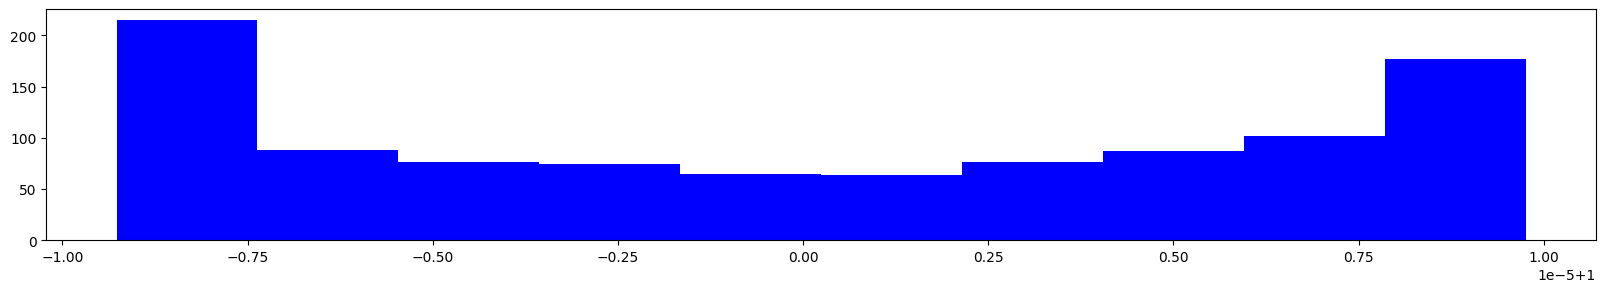

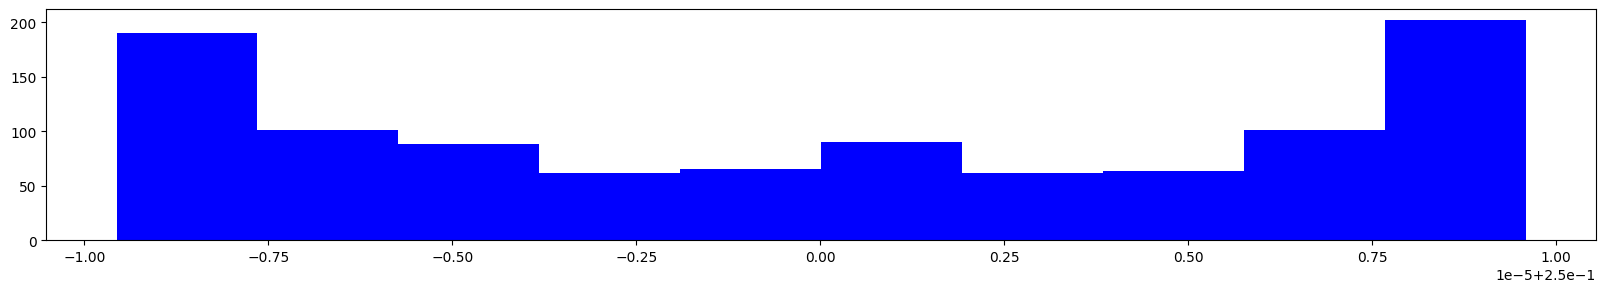

In [4]:
# Plot histogram

plt.figure(figsize=(20, 3))
plt.hist(A2.cpu().numpy(), color='blue')
plt.show()

plt.figure(figsize=(20, 3))
plt.hist(B2.cpu().numpy(), color='blue')
plt.show()

# Other cases have similar histograms
# Note, distribution is not normal (not random)
# It is not symmetric if signal containes more than one component

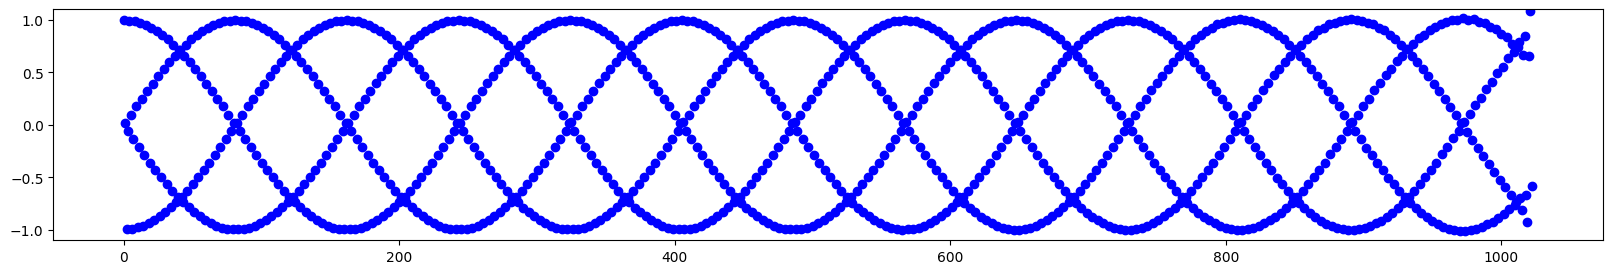

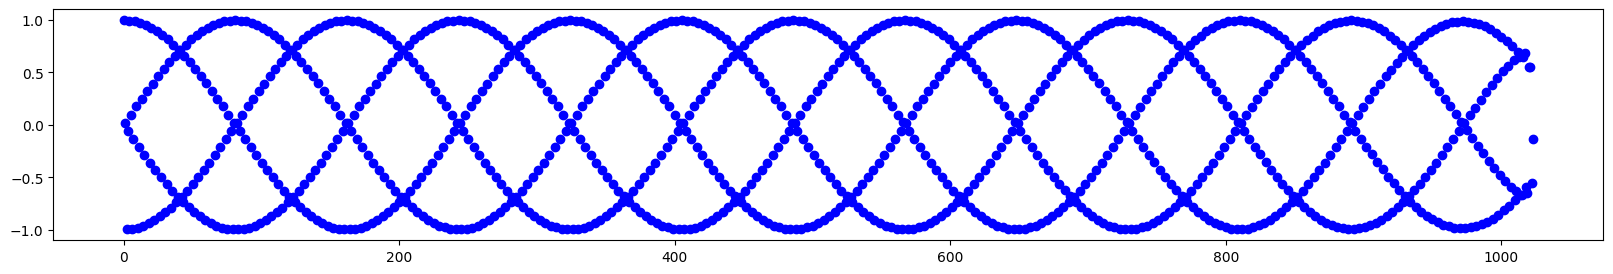

In [5]:
# Plot autocorrelation of estimations

AC = Frequency.autocorrelation(torch.stack([A2-A2.mean()])).flatten().cpu().numpy()
plt.figure(figsize=(20, 3))
plt.scatter(range(limit), AC, color='blue')
plt.ylim(-1.1, +1.1)
plt.show()

AC = Frequency.autocorrelation(torch.stack([B2-B2.mean()])).flatten().cpu().numpy()
plt.figure(figsize=(20, 3))
plt.scatter(range(limit), AC, color='blue')
plt.ylim(-1.1, +1.1)
plt.show()

w1: 3.24955672e-06 2.90046061e-05
w2: 2.76861459e-05 2.81693374e-05


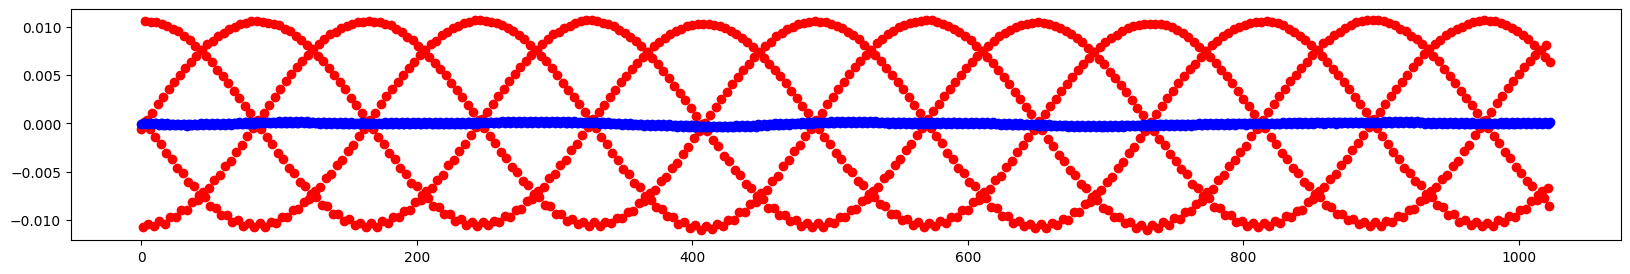

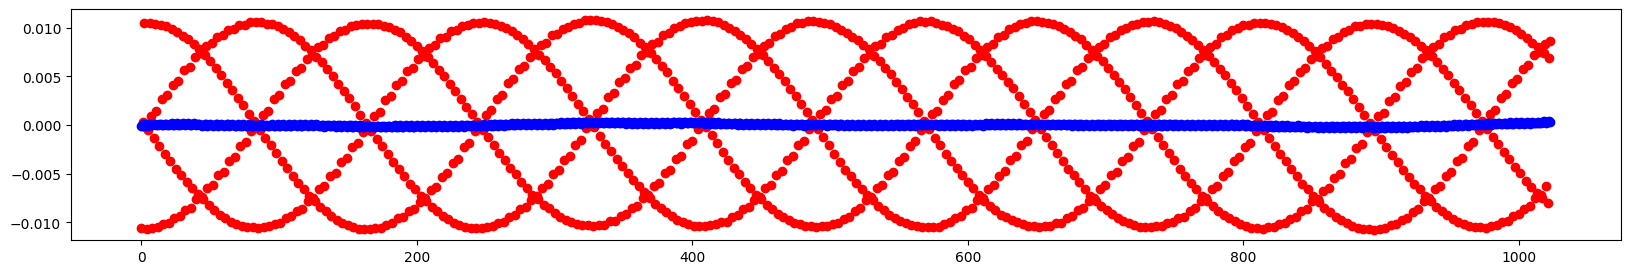

In [6]:
# Estimate parameters for signal with noise

# Set parameters

length = 8192

# Set signal

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)
f = 0.123456789
x = 1.0*torch.cos(0.25 + 2.0*numpy.pi*f*t) + 0.01*torch.cos(0.5 + 2.0*numpy.pi*2*f*t)
x.add_(0.001*torch.randn(length, dtype=dtype, device=device))
x = torch.stack([x])

# Set shift size for starting position

shift = 1

# Set window
# Note, without noise window increases convergence
# With noise window amplifies noise and should be use with care if noise is large
# A possible option is to filter data or to use fractional window order

w1 = Window.from_cosine(128, 0.0, dtype=dtype, device=device)
w2 = Window.from_cosine(128, 0.5, dtype=dtype, device=device)

# Estimate amplitude and phase using shifted samples of length 128
# Note, noise is correlated

A1, B1 = [], []
A2, B2 = [], []
for step in range(limit):
    y = x[:, step*shift: step*shift + 128]
    param, _ = Decomposition.harmonic_sum(f, w1.window, y)
    *_, a, b = param.T
    A1.append(a)
    B1.append(b)
    param, _ = Decomposition.harmonic_sum(f, w2.window, y)
    *_, a, b = param.T
    A2.append(a)
    B2.append(b)

# Format result (amplitude is constant, while phase is shifted)

A1 = torch.stack(A1).flatten()
B1 = torch.stack(B1).flatten()
B1 = mod(B1 - 2.0*numpy.pi*f*shift*torch.linspace(0, limit - 1, limit, dtype=dtype, device=device), 2.0*numpy.pi, -numpy.pi)
A2 = torch.stack(A2).flatten()
B2 = torch.stack(B2).flatten()
B2 = mod(B2 - 2.0*numpy.pi*f*shift*torch.linspace(0, limit - 1, limit, dtype=dtype, device=device), 2.0*numpy.pi, -numpy.pi)

# Compare mean values over samples

print(f'w1: {torch.abs(A1.mean() - 1.0):12.9} {torch.abs(B1.mean() - 0.25):12.9}')
print(f'w2: {torch.abs(A2.mean() - 1.0):12.9} {torch.abs(B2.mean() - 0.25):12.9}')

# Plot estimations for each sample

plt.figure(figsize=(20, 3))
plt.scatter(range(limit), (A1 - 1.00).cpu().numpy(), c='red')
plt.scatter(range(limit), (A2 - 1.00).cpu().numpy(), c='blue')
plt.show()
plt.figure(figsize=(20, 3))
plt.scatter(range(limit), (B1 - 0.25).cpu().numpy(), c='red')
plt.scatter(range(limit), (B2 - 0.25).cpu().numpy(), c='blue')
plt.show()

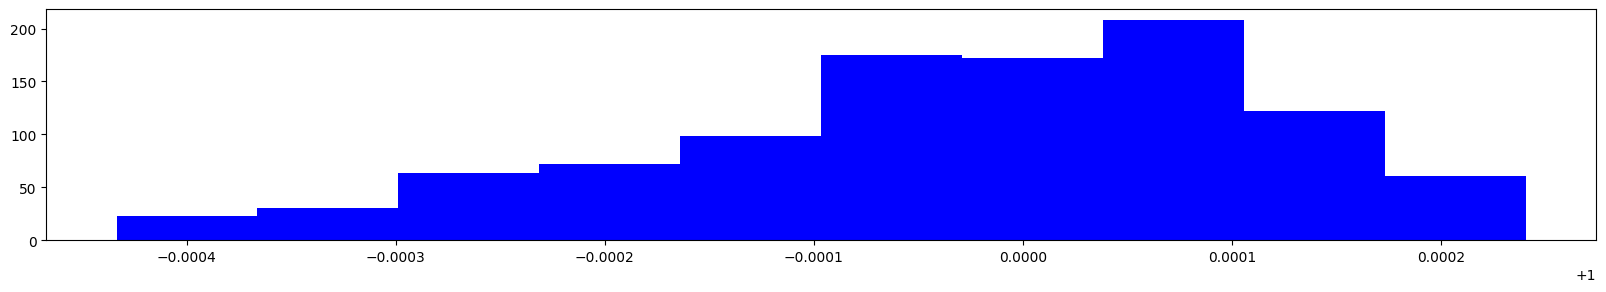

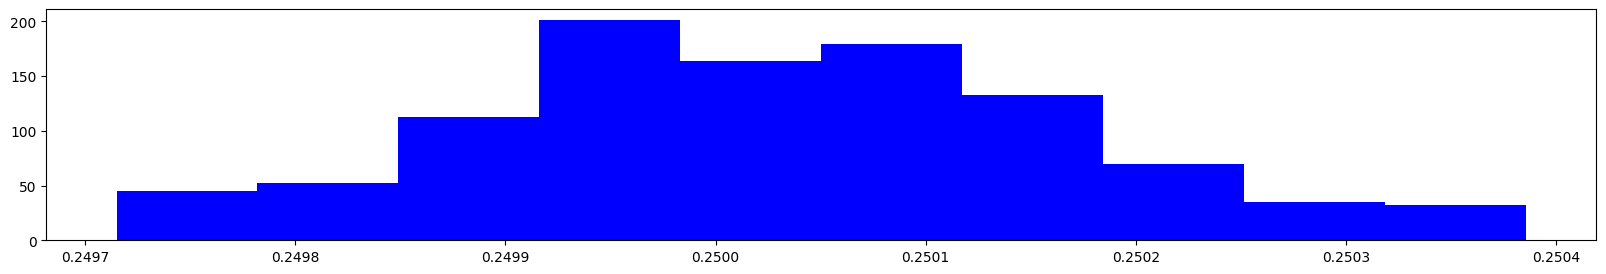

In [7]:
# Plot histogram

plt.figure(figsize=(20, 3))
plt.hist(A2.cpu().numpy(), color='blue')
plt.show()

plt.figure(figsize=(20, 3))
plt.hist(B2.cpu().numpy(), color='blue')
plt.show()

# Other cases have similar histograms
# Note, distribution looks somewhat not normal

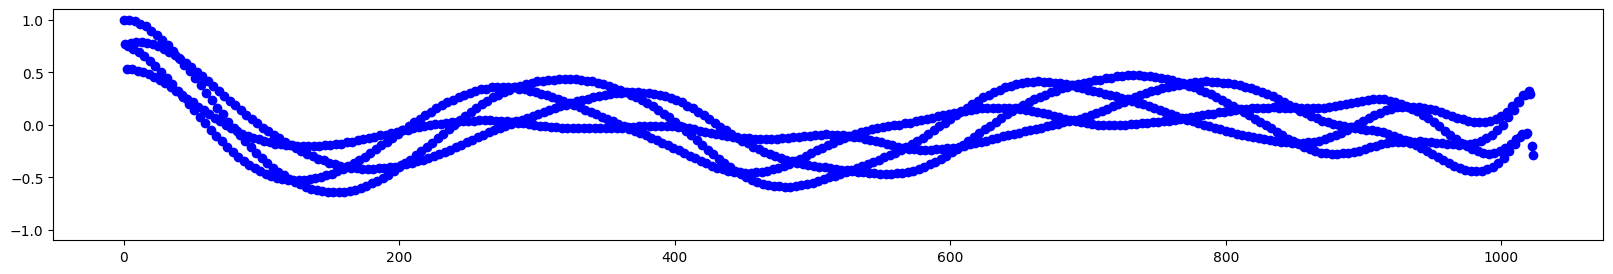

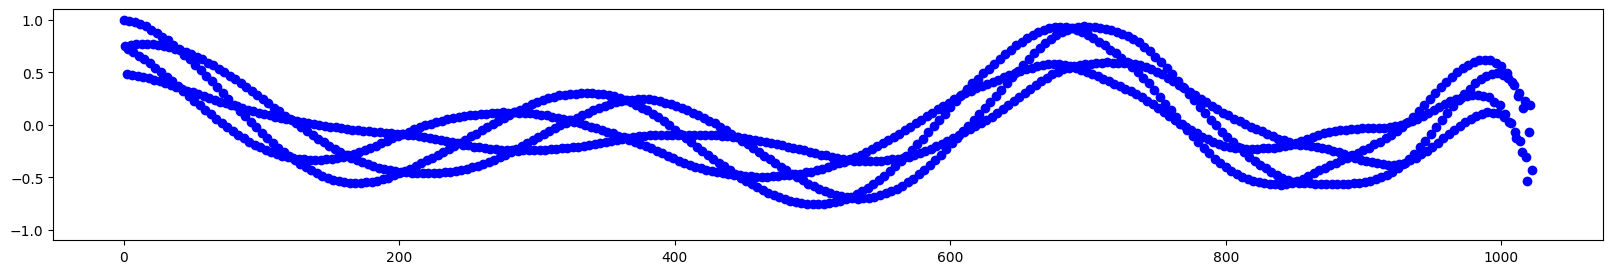

In [8]:
# Plot autocorrelation of estimations

AC = Frequency.autocorrelation(torch.stack([A2-A2.mean()])).flatten().cpu().numpy()
plt.figure(figsize=(20, 3))
plt.scatter(range(limit), AC, color='blue')
plt.ylim(-1.1, +1.1)
plt.show()

AC = Frequency.autocorrelation(torch.stack([B2-B2.mean()])).flatten().cpu().numpy()
plt.figure(figsize=(20, 3))
plt.scatter(range(limit), AC, color='blue')
plt.ylim(-1.1, +1.1)
plt.show()